### archhive ###
https://heasarc.gsfc.nasa.gov/FTP/suzaku/data/obs/1/101002010/auxil/ \
https://data.darts.isas.jaxa.jp/pub/suzaku/DOC/caldb/xis/20090713.html \
https://heasarc.gsfc.nasa.gov/W3Browse/suzaku/suzamaster.html

In [1]:
import numpy as np
from pathlib import Path
import sys
from astropy.io import fits
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
repo_root = Path().resolve().parent  # from notebooks/, go up one
data_dir = repo_root / "data"
if str(data_dir) not in sys.path:
    sys.path.insert(0, str(data_dir))

from darknessalp.yamamoto.suzaku_archive import OBSIDS, load_orbit, load_attitude, load_event, load_ehk, load_calmask
xis = 1
# Load data
calmask0 = load_calmask(xis=xis)

obsid = OBSIDS["LockmanHole"][1]
orbit = load_orbit(obsid)
att   = load_attitude(obsid)
ehk   = load_ehk(obsid)
evt   = load_event(obsid, xis=xis)

print(f"Orbit cols: {list(orbit.keys())[:5]}")
print(f"EHK cols:   {list(ehk.keys())[:5]}")
print("EHK keys:", list(ehk.keys())[:10])
print("Orbit columns:", orbit.keys())
print("Attitude columns:", att.keys())
print("Event shape:", evt["X"].shape, evt["Y"].shape)

Orbit cols: ['EPOCH', 'A', 'E', 'I', 'AN']
EHK cols:   ['TIME', 'YYYYMMDD', 'HHMMSS', 'EULER1', 'EULER2']
EHK keys: ['TIME', 'YYYYMMDD', 'HHMMSS', 'EULER1', 'EULER2', 'EULER3', 'FOC_RA', 'FOC_DEC', 'FOC_ROLL', 'DLT_RA']
Orbit columns: dict_keys(['EPOCH', 'A', 'E', 'I', 'AN', 'AP', 'MA', 'A.DOT', 'E.DOT', 'I.DOT', 'AN.DOT', 'AP.DOT', 'N', 'T', 'TIME', 'YYYYMMDD', 'HHMMSS'])
Attitude columns: dict_keys(['TIME', 'YYYYMMDD', 'HHMMSS', 'JD', 'EULER', 'DELTA', 'STATUS', 'ACP_RESI', 'IRU_DRIFT', 'IRU_DELTA', 'KALMAN_GAIN', 'STTA_RESI', 'STTB_RESI', 'NSAS_RESI', 'EULER_OLD', 'XOFFSET', 'YOFFSET', 'T_86', 'T_DY', 'FLAG_ATTCOR'])


TypeError: tuple indices must be integers or slices, not str

CALMASK unique values: [0. 1.]
CALMASK shape: (1024, 1024)
Fraction marked as bad: 0.899
Loaded 16,225 total events
After EHK filters: 12,483 events
After CALMASK inversion: 8,638 science photons
Potential cosmic rays (PI > 1500): 8,638


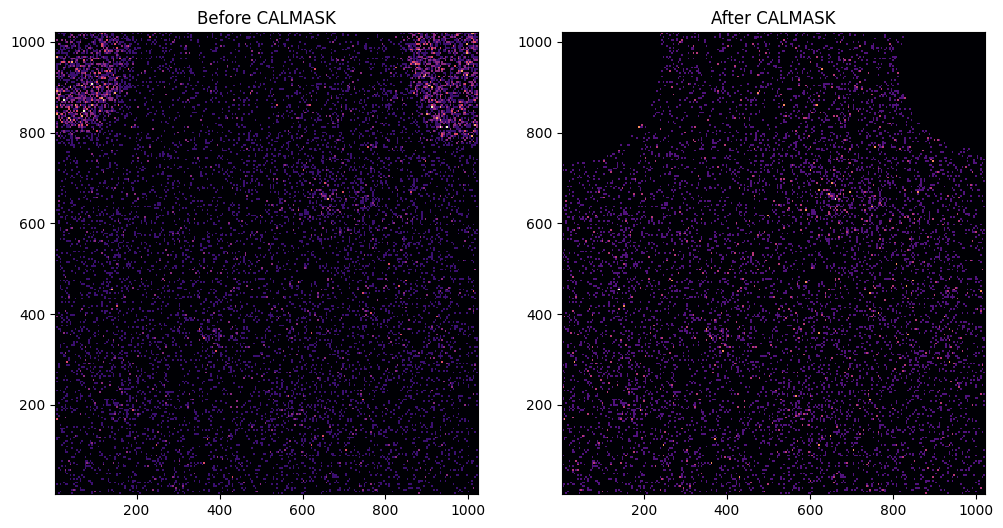

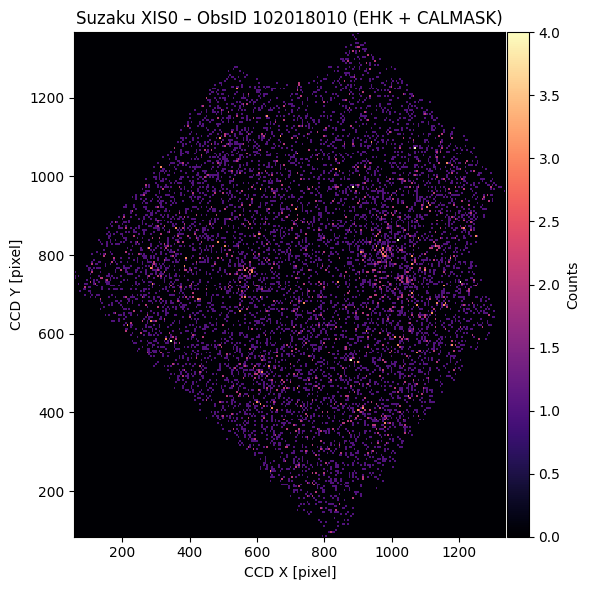

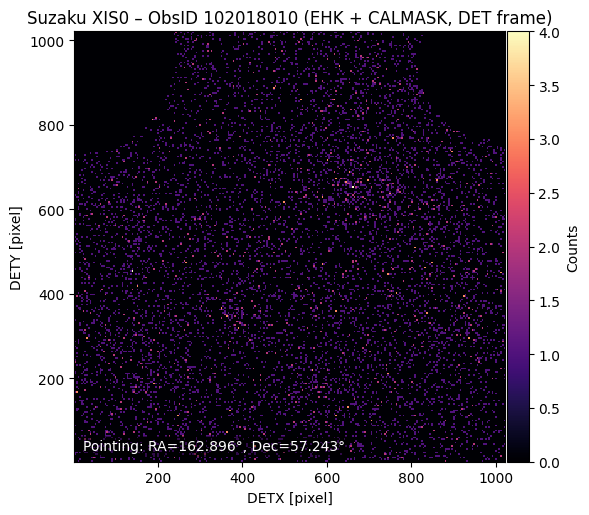

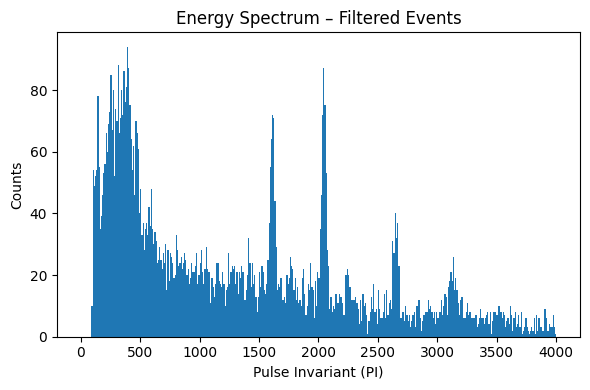

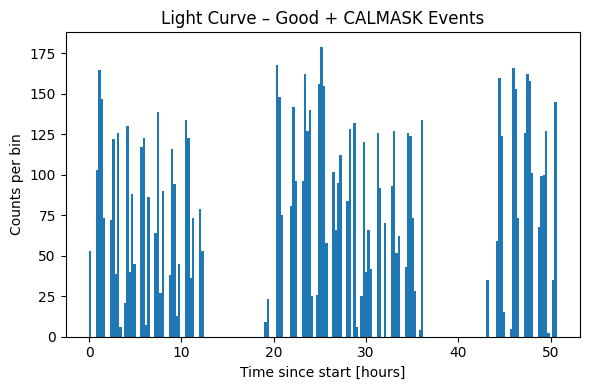

In [17]:
# %% Minimal Suzaku Observation Quicklook (modular version)
import numpy as np
import sys
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

# --- Import the unified loaders --------------------------------------------
repo_root = Path().resolve().parent       # from notebooks/, go up one
data_dir = repo_root / "data"
if str(data_dir) not in sys.path:
    sys.path.insert(0, str(data_dir))

from darknessalp.yamamoto.suzaku_archive import (
    OBSIDS, load_orbit, load_attitude, load_event, load_ehk, load_calmask
)

xis = 0
# --- Load data -------------------------------------------------------------
calmask = load_calmask(xis=xis)
print(f"CALMASK unique values: {np.unique(calmask)}")
print(f"CALMASK shape: {calmask.shape}")
print(f"Fraction marked as bad: {(calmask != 0).sum() / calmask.size:.3f}")

obsid = OBSIDS["LockmanHole"][1]

orbit = load_orbit(obsid)
att   = load_attitude(obsid)
ehk   = load_ehk(obsid)
evt, hdul = load_event(obsid, xis=xis)


print(f"Loaded {len(evt['TIME']):,} total events")

# --- EHK filtering ---------------------------------------------------------
evt_time = evt["TIME"]
ehk_time = ehk["TIME"]
interp = lambda key: np.interp(evt_time, ehk_time, ehk[key])

good_mask = (
    (interp("SAA") < 0.5) &
    (interp("ELV") > 5) &
    (interp("DYE_ELV") > 20) &
    (interp("COR2") > 8)
)
evt_filtered = {k: v[good_mask] for k, v in evt.items()}
print(f"After EHK filters: {len(evt_filtered['TIME']):,} events")

# --- Apply CALMASK (invert to exclude Fe-55 corners) ----------------------
x = np.clip(evt_filtered["DETX"].astype(int), 0, calmask.shape[1]-1)
y = np.clip(evt_filtered["DETY"].astype(int), 0, calmask.shape[0]-1)
science_mask = (calmask[y, x] != 0)

E = {k: v[science_mask] for k, v in evt_filtered.items()}
print(f"After CALMASK inversion: {len(E['TIME']):,} science photons")

# --- Filter for high-energy events (cosmic rays) --------------------------
cosmic_mask = E["PI"] > 7  # Adjust threshold as needed
cosmic_events = {k: v[cosmic_mask] for k, v in E.items()}
print(f"Potential cosmic rays (PI > 1500): {len(cosmic_events['TIME']):,}")

# Before applying CALMASK, check what you're filtering out
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
ax1.hist2d(evt_filtered["DETX"], evt_filtered["DETY"], bins=256, cmap="magma")
ax1.set_title("Before CALMASK")
ax2.hist2d(E["DETX"], E["DETY"], bins=256, cmap="magma")
ax2.set_title("After CALMASK")
plt.show()

# --- 1. CCD image ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6,6))
im = ax.hist2d(E["X"], E["Y"], bins=256, cmap="magma")
ax.set_xlabel("CCD X [pixel]")
ax.set_ylabel("CCD Y [pixel]")
ax.set_title(f"Suzaku XIS0 – ObsID {obsid} (EHK + CALMASK)")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.02)
cb = fig.colorbar(im[3], cax=cax)
cb.set_label("Counts")
plt.tight_layout()
plt.show()

# --- 2. DET coordinates ----------------------------------------------------
fig, ax = plt.subplots(figsize=(6,6))

# Use detector-plane coordinates (these preserve instrument orientation)
im = ax.hist2d(E["DETX"], E["DETY"], bins=256, cmap="magma")

ax.set_xlabel("DETX [pixel]")
ax.set_ylabel("DETY [pixel]")
ax.set_title(f"Suzaku XIS0 – ObsID {obsid} (EHK + CALMASK, DET frame)")
ax.axis("equal")

# Add pointing coordinates annotation (from event header)
ra_pnt = hdul[0].header.get("RA_PNT", np.nan)
dec_pnt = hdul[0].header.get("DEC_PNT", np.nan)
ax.text(
    0.02, 0.02,
    f"Pointing: RA={ra_pnt:.3f}°, Dec={dec_pnt:.3f}°",
    color="white", fontsize=10,
    transform=ax.transAxes, ha="left", va="bottom",
    bbox=dict(facecolor="black", alpha=0.4, edgecolor="none", pad=2.5)
)

# Colorbar and layout
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.02)
cb = fig.colorbar(im[3], cax=cax)
cb.set_label("Counts")
plt.tight_layout()
plt.show()


# --- 3. Energy spectrum ----------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(E["PI"], bins=400, range=(0,4000))
plt.xlabel("Pulse Invariant (PI)")
plt.ylabel("Counts")
plt.title("Energy Spectrum – Filtered Events")
plt.tight_layout()
plt.show()

# --- 4. Light curve --------------------------------------------------------
t = E["TIME"] - E["TIME"][0]
plt.figure(figsize=(6,4))
plt.hist(t/3600, bins=200)
plt.xlabel("Time since start [hours]")
plt.ylabel("Counts per bin")
plt.title("Light Curve – Good + CALMASK Events")
plt.tight_layout()
plt.show()
